# Predicting Missing Values with Regression

## A leakage-aware age-imputation case study

Missing-value imputation is a prediction problem with an unusual test set: the values we ultimately want to predict are hidden. This notebook uses Titanic passenger age to show how to validate a regression imputer on observed values, compare it with a simple baseline, and preserve the uncertainty that a single fitted number hides.


## 1. Start with the purpose

There is no universally best way to fill a blank. The right treatment depends on the analysis that follows.

- **For a predictive model:** keep imputation inside the model pipeline. Fit it on each training fold, add a missingness indicator when absence may be informative, and judge the final model—not the visual plausibility of the filled column.
- **For descriptive statistics or inference:** a single deterministic fill makes the sample look more certain than it is. Multiple imputation or a sensitivity analysis is usually more defensible.
- **For an operational field:** first ask whether the value can be recovered from a source system. Prediction should not replace data repair.

Here the exercise is to reconstruct missing `Age` values. We will not use `Survived` as a predictor. If the completed age column is later used to predict survival, using the outcome to create that feature would leak the answer into the input.

### Learning goals

By the end, you will be able to:

1. distinguish MCAR, MAR, and MNAR assumptions;
2. audit the pattern of missingness without claiming that a chart proves its mechanism;
3. validate an imputer by hiding values that are actually known;
4. compare regression with a median baseline using MAE, RMSE, and $R^2$;
5. fit preprocessing and regression as one pipeline;
6. retain an `Age_missing` indicator and explain why point imputation shrinks variance; and
7. produce several residual-draw datasets for sensitivity analysis.

**Data:** the public Titanic training data originally used in Kaggle's introductory competition. The notebook uses `data/titanic.csv` when present and otherwise downloads the DataScience Dojo mirror.


## 2. What can the missingness depend on?

Let $R=1$ mean that age is observed.

- **MCAR — Missing Completely At Random:** $R$ is unrelated to age and to every measured variable. Complete cases are still representative, apart from lost precision.
- **MAR — Missing At Random, conditional on observed data:** after conditioning on variables such as passenger class, title, and fare, whether age is missing no longer depends on the unobserved age. Regression imputation relies on an assumption like this.
- **MNAR — Missing Not At Random:** even after conditioning on what we recorded, missingness still depends on the age that is absent—for example, if ages were omitted more often for very young passengers.

Observed data cannot prove MAR rather than MNAR. We can show that missingness varies across observed groups, make the assumption explicit, and test whether conclusions change under plausible alternatives.


In [1]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython import get_ipython
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import sklearn

get_ipython().run_line_magic("matplotlib", "inline")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42
AGE_MIN, AGE_MAX = 0, 100

print(f"pandas {pd.__version__} | scikit-learn {sklearn.__version__}")


pandas 2.3.3 | scikit-learn 1.8.0


In [2]:
LOCAL_PATHS = [Path("data/titanic.csv"), Path("titanic.csv")]
DATA_URL = (
    "https://raw.githubusercontent.com/datasciencedojo/"
    "datasets/master/titanic.csv"
)

local_path = next((path for path in LOCAL_PATHS if path.exists()), None)
if local_path is None:
    local_path = Path("data/titanic.csv")
    local_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, local_path)
    data_source = DATA_URL
else:
    data_source = local_path

df = pd.read_csv(local_path)
required = {
    "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Fare", "Cabin", "Embarked",
}
missing_columns = required.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing expected columns: {sorted(missing_columns)}")

print(f"Loaded {df.shape[0]:,} passengers × {df.shape[1]} columns from {data_source}")
df.head(3)


Loaded 891 passengers × 12 columns from data\titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 3. Audit before filling

`Age` is absent for 177 of 891 passengers (19.9%). `Cabin` is absent much more often, and `Embarked` is missing twice. These are separate data problems; a model trained specifically for age should not silently claim to solve the others.

The group table below is diagnostic, not a test of the missingness mechanism. Different missing rates by class or title reject the simplest MCAR story, but they do not establish MAR. The missing ages themselves remain unknown.


,missing,rate,dtype
Cabin,687,77.1%,object
Age,177,19.9%,float64
Embarked,2,0.2%,object


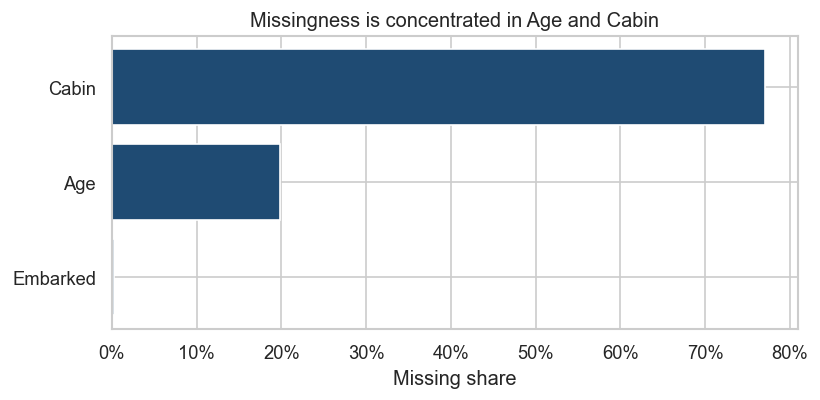

In [3]:
missingness = (
    pd.DataFrame(
        {
            "missing": df.isna().sum(),
            "rate": df.isna().mean(),
            "dtype": df.dtypes.astype(str),
        }
    )
    .query("missing > 0")
    .sort_values("rate", ascending=False)
)
display(
    missingness.style.format(
        {"missing": "{:,.0f}", "rate": "{:.1%}"}
    )
)

df["Age_missing"] = df["Age"].isna()
assert df["Age_missing"].sum() == 177

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(missingness.index[::-1], missingness["rate"].iloc[::-1], color="#1f4b73")
ax.set_xlabel("Missing share")
ax.set_title("Missingness is concentrated in Age and Cabin")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
fig.tight_layout()
plt.show()


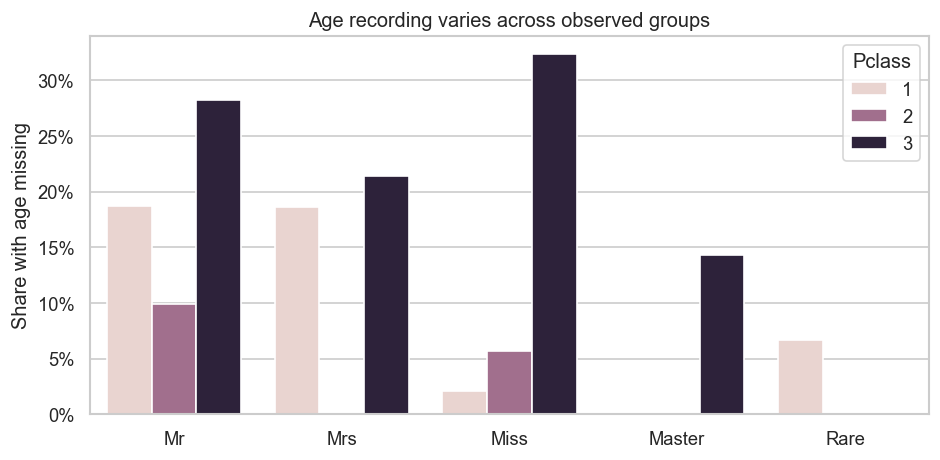

In [4]:
# Titles are available for every passenger and carry age information:
# Master, Miss, Mrs, and Mr refer to different age distributions.
df["Title"] = (
    df["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
    .replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
)
common_titles = {"Mr", "Miss", "Mrs", "Master"}
df["Title"] = df["Title"].where(df["Title"].isin(common_titles), "Rare")

missing_by_group = (
    df.groupby(["Pclass", "Title"], observed=True)
    .agg(passengers=("PassengerId", "size"), age_missing_rate=("Age_missing", "mean"))
    .query("passengers >= 10")
    .sort_values("age_missing_rate", ascending=False)
)
display(
    missing_by_group.style.format(
        {"passengers": "{:,.0f}", "age_missing_rate": "{:.1%}"}
    )
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=df,
    x="Title",
    y="Age_missing",
    hue="Pclass",
    errorbar=None,
    ax=ax,
)
ax.set_ylabel("Share with age missing")
ax.set_xlabel("")
ax.set_title("Age recording varies across observed groups")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
fig.tight_layout()
plt.show()


## 4. Design the imputation model

The target is `Age`. Candidate predictors must be available wherever the imputed age will be used:

- numeric: `Pclass`, `SibSp`, `Parch`, `Fare`;
- categorical: `Sex`, `Embarked`, and the title extracted from `Name`.

We intentionally exclude:

- `Survived`, because age may later be used to model survival;
- `PassengerId`, which is a row identifier;
- `Ticket` and `Cabin`, whose raw strings are high-cardinality identifiers, and whose useful structure would require separate feature engineering.

The preprocessing pipeline median-fills numeric predictors, most-frequent-fills categorical predictors, one-hot encodes categories, and handles a category that was absent from a training fold. All of it is fitted inside each validation fold.


In [5]:
FEATURES = ["Pclass", "Sex", "SibSp", "Parch", "Fare", "Embarked", "Title"]
NUMERIC_FEATURES = ["Pclass", "SibSp", "Parch", "Fare"]
CATEGORICAL_FEATURES = ["Sex", "Embarked", "Title"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
    ]
)
preprocess = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

linear_imputer = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression()),
    ]
)
median_imputer = DummyRegressor(strategy="median")

known_age = df.loc[df["Age"].notna()].copy()
X_known = known_age[FEATURES]
y_known = known_age["Age"]
print(f"Rows available for validation and fitting: {len(known_age):,}")


Rows available for validation and fitting: 714


## 5. Validate by hiding known ages

The 177 missing ages cannot be used to calculate an error: their true values are missing. Instead, ten-fold cross-validation repeatedly hides part of the 714 known ages, fits on the rest, and predicts the held-out fold. Every known age receives one out-of-fold prediction.

The baseline always predicts the training fold's median age. A regression imputer needs to beat that baseline to justify its added assumptions.

We use:

- **MAE:** typical absolute error in years; the easiest number to explain;
- **RMSE:** penalizes large misses more strongly;
- **$R^2$:** fraction of variation explained relative to a mean prediction.

MAPE is a poor metric here because ages include infants near zero. It would give extreme percentage errors to small denominators. Its call signature is also `metric(y_true, y_pred)`, not the reverse.


In [6]:
cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
models = {
    "Median baseline": median_imputer,
    "Linear regression": linear_imputer,
}

oof_predictions = {}
rows = []
for name, model in models.items():
    predicted = cross_val_predict(model, X_known, y_known, cv=cv)
    predicted = np.clip(predicted, AGE_MIN, AGE_MAX)
    oof_predictions[name] = predicted
    rows.append(
        {
            "model": name,
            "MAE (years)": mean_absolute_error(y_known, predicted),
            "RMSE (years)": mean_squared_error(y_known, predicted) ** 0.5,
            "R²": r2_score(y_known, predicted),
        }
    )

validation = pd.DataFrame(rows).set_index("model")
display(validation.style.format("{:.2f}"))

assert validation.loc["Linear regression", "MAE (years)"] < validation.loc[
    "Median baseline", "MAE (years)"
]
assert validation.loc["Linear regression", "R²"] > 0


,MAE (years),RMSE (years),R²
model,,,
Median baseline,11.27,14.63,-0.02
Linear regression,8.85,11.24,0.40


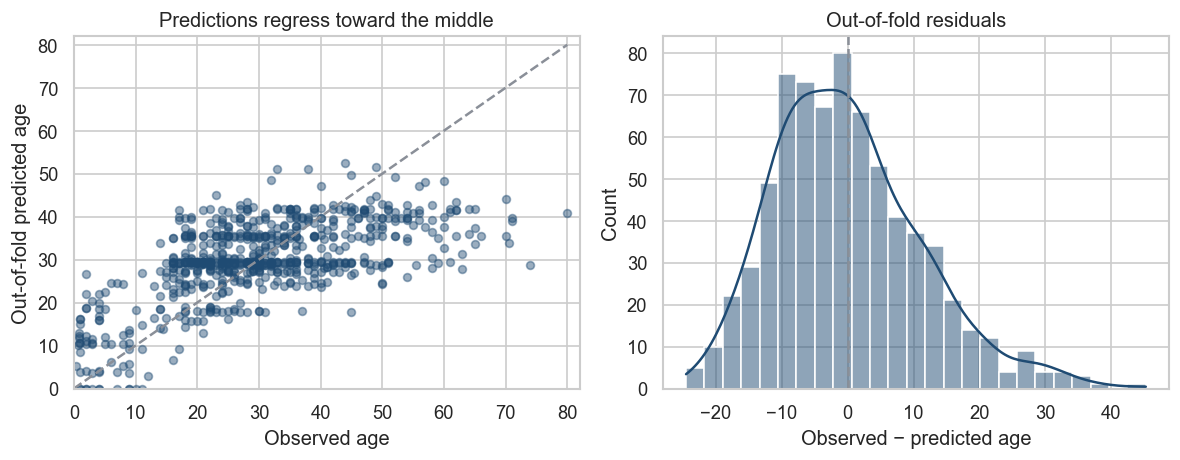

Residual median: -1.2 years | central 80%: -13.2 to 14.7


In [7]:
linear_oof = oof_predictions["Linear regression"]
residuals = y_known.to_numpy() - linear_oof

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_known, linear_oof, alpha=0.45, s=22, color="#1f4b73")
axes[0].plot([0, 80], [0, 80], linestyle="--", color="#8a8f98")
axes[0].set(
    xlabel="Observed age",
    ylabel="Out-of-fold predicted age",
    title="Predictions regress toward the middle",
    xlim=(0, 82),
    ylim=(0, 82),
)

sns.histplot(residuals, bins=25, kde=True, color="#1f4b73", ax=axes[1])
axes[1].axvline(0, linestyle="--", color="#8a8f98")
axes[1].set(
    xlabel="Observed − predicted age",
    title="Out-of-fold residuals",
)
fig.tight_layout()
plt.show()

print(
    f"Residual median: {np.median(residuals):.1f} years | "
    f"central 80%: {np.quantile(residuals, 0.10):.1f} to "
    f"{np.quantile(residuals, 0.90):.1f}"
)


The linear model reduces MAE by roughly two and a half years compared with median filling, but an error near nine years is still substantial. The scatterplot also shows **regression to the mean**: low ages are often predicted too high and high ages too low. A plausible-looking decimal is not a recovered fact.

Cross-validation estimates performance under a key transport assumption: passengers whose ages are missing follow the same age–predictor relationship as passengers whose ages were recorded, after conditioning on the included variables. If missingness is MNAR, this estimate can be optimistic.


## 6. Fit once and create the point-imputed column

Now—and only now—we fit on every observed age. Predictions are clipped to a defensible physical range instead of rounded to integers. The source itself contains fractional infant ages, and rounding adds error without adding information.

We keep:

- `Age_observed`: the untouched source value;
- `Age_missing`: whether the source value was absent;
- `Age_imputed`: observed age where available, otherwise the model prediction.

Keeping the indicator lets downstream work distinguish recorded data from generated data.


In [8]:
linear_imputer.fit(X_known, y_known)

missing_mask = df["Age"].isna()
point_predictions = np.clip(
    linear_imputer.predict(df.loc[missing_mask, FEATURES]),
    AGE_MIN,
    AGE_MAX,
)

df_imputed = df.copy()
df_imputed["Age_observed"] = df_imputed["Age"]
df_imputed.loc[missing_mask, "Age"] = point_predictions
df_imputed = df_imputed.rename(columns={"Age": "Age_imputed"})

assert df_imputed["Age_observed"].isna().sum() == 177
assert df_imputed["Age_imputed"].isna().sum() == 0
assert df_imputed.loc[~missing_mask, "Age_imputed"].equals(
    df_imputed.loc[~missing_mask, "Age_observed"]
)

print(
    f"Filled {missing_mask.sum():,} ages; predictions range from "
    f"{point_predictions.min():.1f} to {point_predictions.max():.1f} years."
)
display(
    df_imputed.loc[
        missing_mask,
        ["PassengerId", "Pclass", "Sex", "Title", "Age_observed", "Age_imputed", "Age_missing"],
    ].head(10)
)


Filled 177 ages; predictions range from 0.0 to 47.1 years.


,PassengerId,Pclass,Sex,Title,Age_observed,Age_imputed,Age_missing
5,6,3,male,Mr,NaN,34.888327,True
17,18,2,male,Mr,NaN,35.429661,True
19,20,3,female,Mrs,NaN,29.758158,True
26,27,3,male,Mr,NaN,27.337067,True
28,29,3,female,Miss,NaN,23.897392,True
29,30,3,male,Mr,NaN,29.262422,True
31,32,1,female,Mrs,NaN,39.386092,True
32,33,3,female,Miss,NaN,23.898147,True
36,37,3,male,Mr,NaN,27.337042,True
42,43,3,male,Mr,NaN,27.333146,True


,count,mean,std,min,median,max
group,,,,,,
Observed ages,714.0,29.7,14.5,0.4,28.0,80.0
Point predictions for missing ages,177.0,29.2,9.0,0.0,29.3,47.1


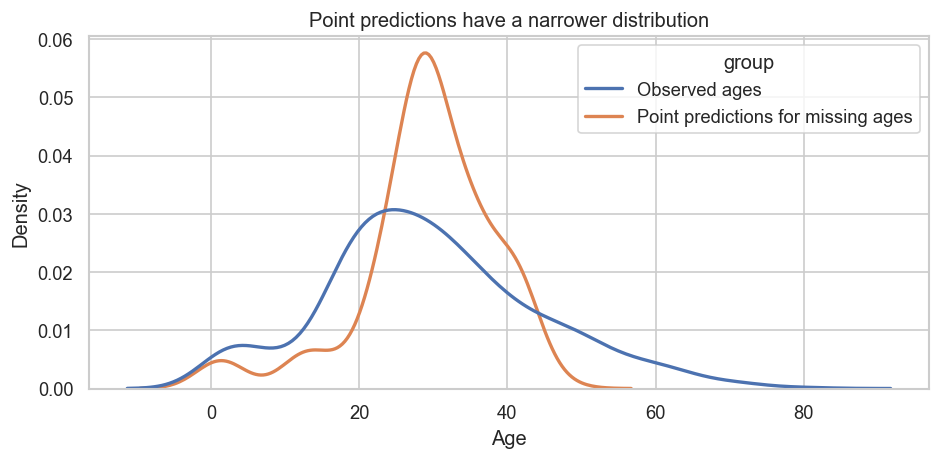

In [9]:
distribution = pd.DataFrame(
    {
        "group": np.repeat("Observed ages", y_known.size),
        "age": y_known.to_numpy(),
    }
)
distribution = pd.concat(
    [
        distribution,
        pd.DataFrame(
            {
                "group": "Point predictions for missing ages",
                "age": point_predictions,
            }
        ),
    ],
    ignore_index=True,
)

display(
    distribution.groupby("group")["age"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .style.format("{:.1f}")
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(
    data=distribution,
    x="age",
    hue="group",
    common_norm=False,
    fill=False,
    linewidth=2,
    ax=ax,
)
ax.set_xlabel("Age")
ax.set_title("Point predictions have a narrower distribution")
fig.tight_layout()
plt.show()


The point predictions have much less spread than observed age. This is expected: ordinary regression estimates the conditional mean, not an individual passenger's exact age. Replacing every missing value with a conditional mean preserves some relationships but understates uncertainty and can weaken variance, correlations, and standard errors.

## 7. A sensitivity analysis with residual draws

One simple improvement is **stochastic regression imputation**:

1. predict the conditional mean;
2. sample an out-of-fold residual;
3. add it to the prediction and enforce the physical bounds.

The code below creates five completed age columns. Their variation shows how much an analysis may move when plausible residual uncertainty is restored. This is useful for teaching and sensitivity checks, but it is not automatically a formal multiple-imputation analysis. Formal inference also needs an imputation model appropriate to the data and a pooling rule for estimates and standard errors.


In [10]:
rng = np.random.default_rng(RANDOM_STATE)
sensitivity_ages = {}
for draw in range(1, 6):
    sampled_residuals = rng.choice(residuals, size=missing_mask.sum(), replace=True)
    stochastic_predictions = np.clip(
        point_predictions + sampled_residuals,
        AGE_MIN,
        AGE_MAX,
    )
    completed = df["Age"].copy()
    completed.loc[missing_mask] = stochastic_predictions
    sensitivity_ages[f"Age_draw_{draw}"] = completed

sensitivity = pd.DataFrame(sensitivity_ages)
draw_summary = (
    sensitivity.loc[missing_mask]
    .agg(["mean", "std", "min", "median", "max"])
    .T
)
display(draw_summary.style.format("{:.1f}"))

assert sensitivity.isna().sum().sum() == 0


,mean,std,min,median,max
Age_draw_1,28.9,14.1,0.0,28.8,69.7
Age_draw_2,29.7,15.1,0.0,29.4,69.6
Age_draw_3,29.6,14.3,0.0,29.2,74.8
Age_draw_4,29.2,13.4,0.0,29.1,73.0
Age_draw_5,30.1,16.4,0.0,31.4,74.9


## 8. What to use in practice

**For downstream prediction**

Put `SimpleImputer` (often with `add_indicator=True`) or another chosen imputer inside the downstream estimator's pipeline. Validate the complete pipeline. A separate, globally filled CSV lets information cross validation folds and makes the experiment optimistic.

**For an analysis that needs a completed age variable**

Use the point-imputed column only when the limitations are acceptable. Report the missing fraction, the validation MAE, predictors, bounds, and missingness assumption. For inference, use a multiple-imputation method and pool results across completed datasets.

**Current scikit-learn options**

- `SimpleImputer`: mean, median, most-frequent, constant, or callable univariate filling; fast and a strong baseline.
- `KNNImputer`: averages nearby rows using the observed coordinates; sensitive to scaling and the distance definition.
- `IterativeImputer`: round-robin multivariate regression. In scikit-learn 1.8 it remains experimental and returns one imputation by default. Repeated posterior sampling can generate multiple completed datasets, but preprocessing categorical variables and pooling the final analysis are still the analyst's responsibility.

### Checks

1. Remove `Title` from the feature list and rerun validation. Which age groups become harder to predict?
2. Add `Survived` and observe the score change. Then explain why that score cannot justify using the feature when survival is the later target.
3. Compare the standard deviation of point predictions with each residual-draw column.
4. Change the random seed. The point imputation should stay fixed; the sensitivity draws should change.

The completed point dataset is available as `df_imputed`. It is deliberately not written to disk automatically.
